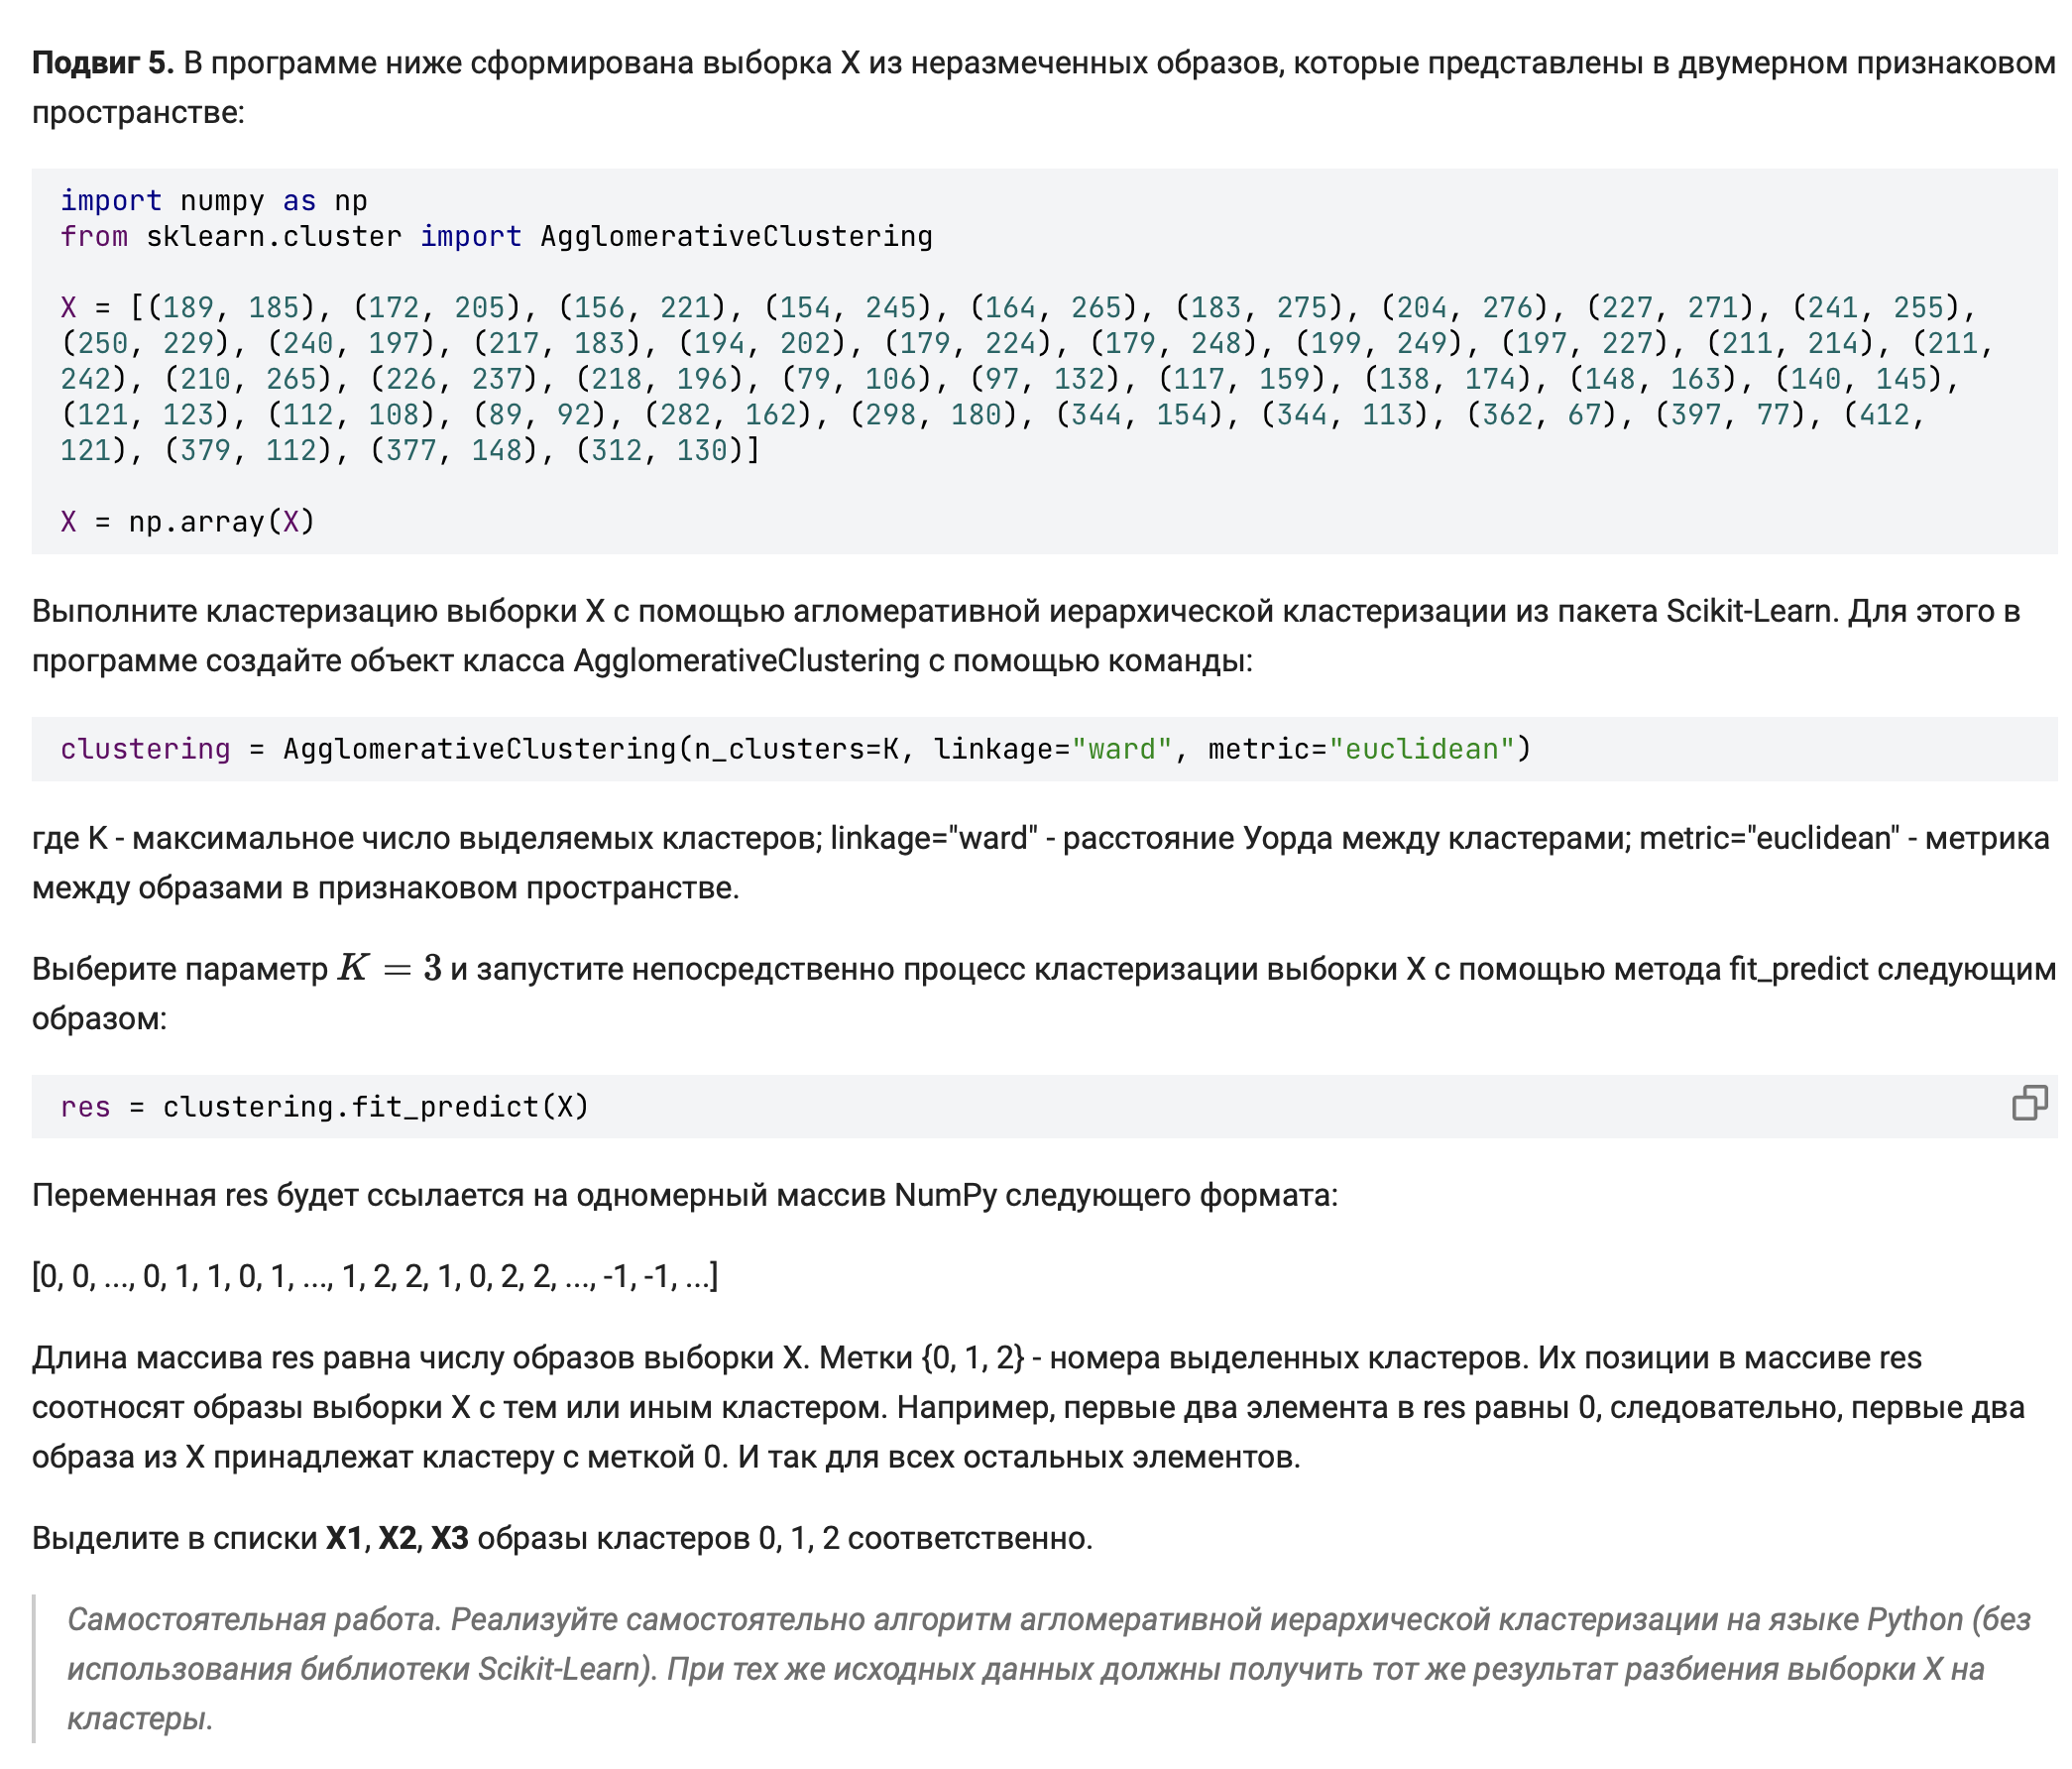

In [2]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

X = [(189, 185), (172, 205), (156, 221), (154, 245), (164, 265), (183, 275), (204, 276), (227, 271), (241, 255), (250, 229), (240, 197), (217, 183), (194, 202), (179, 224), (179, 248), (199, 249), (197, 227), (211, 214), (211, 242), (210, 265), (226, 237), (218, 196), (79, 106), (97, 132), (117, 159), (138, 174), (148, 163), (140, 145), (121, 123), (112, 108), (89, 92), (282, 162), (298, 180), (344, 154), (344, 113), (362, 67), (397, 77), (412, 121), (379, 112), (377, 148), (312, 130)]

X = np.array(X)

# здесь продолжайте программу
K = 3
clustering = AgglomerativeClustering(n_clusters=K, linkage='ward', metric='euclidean')
res = clustering.fit_predict(X)
X1, X2, X3 = [X[res == i] for i in range(K)]

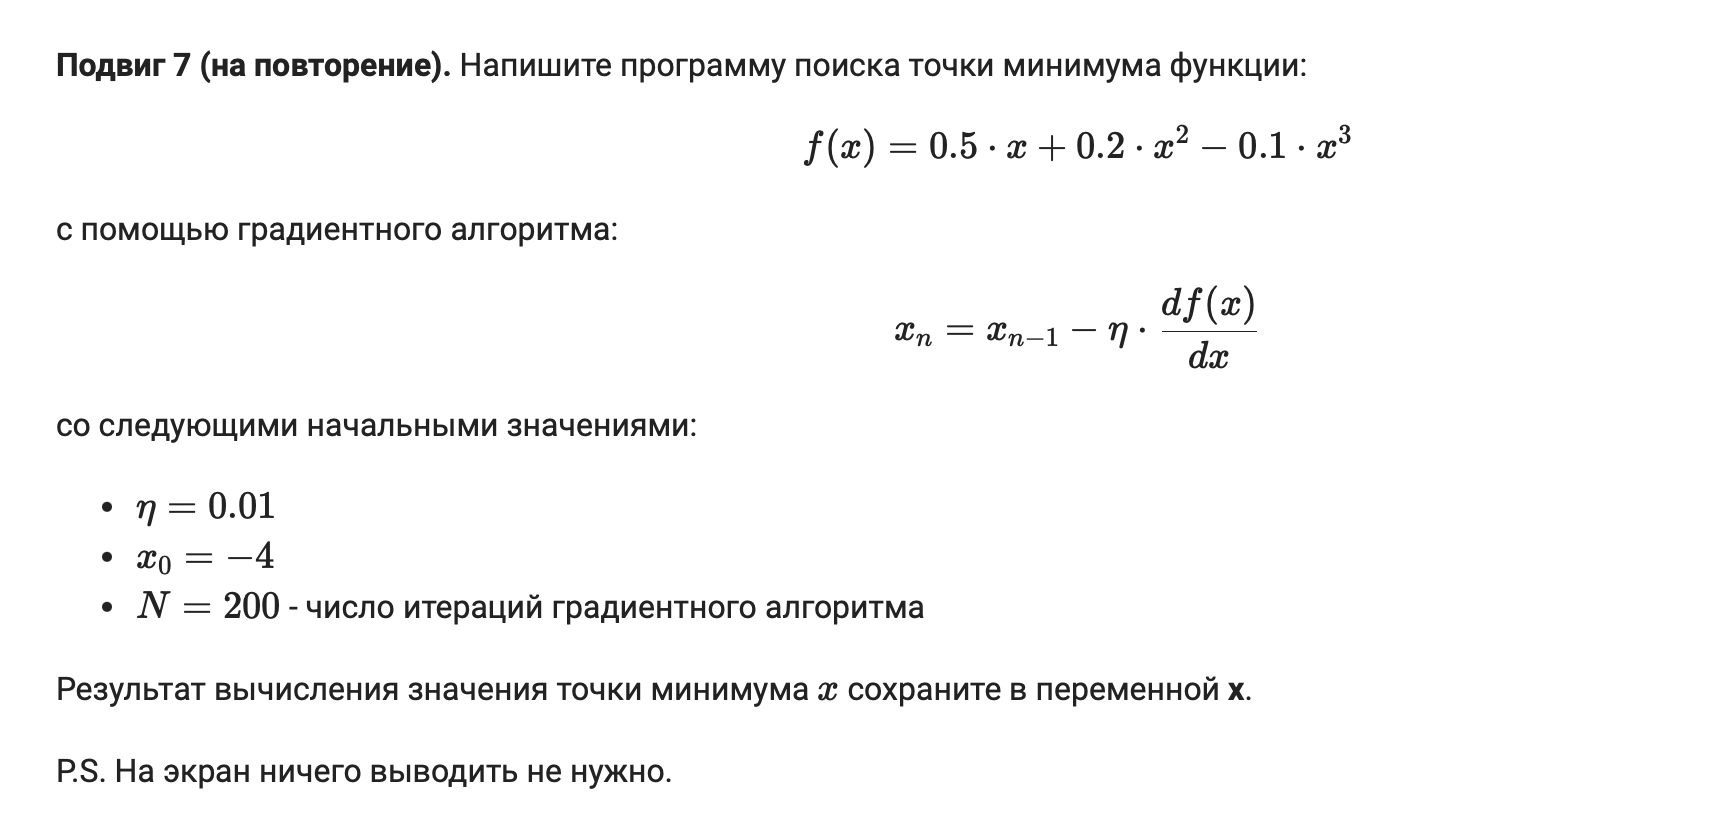

In [3]:
import numpy as np


def func(x):
    return 0.5 * x + 0.2 * x ** 2 - 0.1 * x ** 3


def df(x):
    return 0.5 + 0.4*x - 0.3*x**2


# здесь продолжайте программу
nu = 0.01
x0 = -4
N = 200

for i in range(N):
    x0 -= nu * df(x0)
x = x0

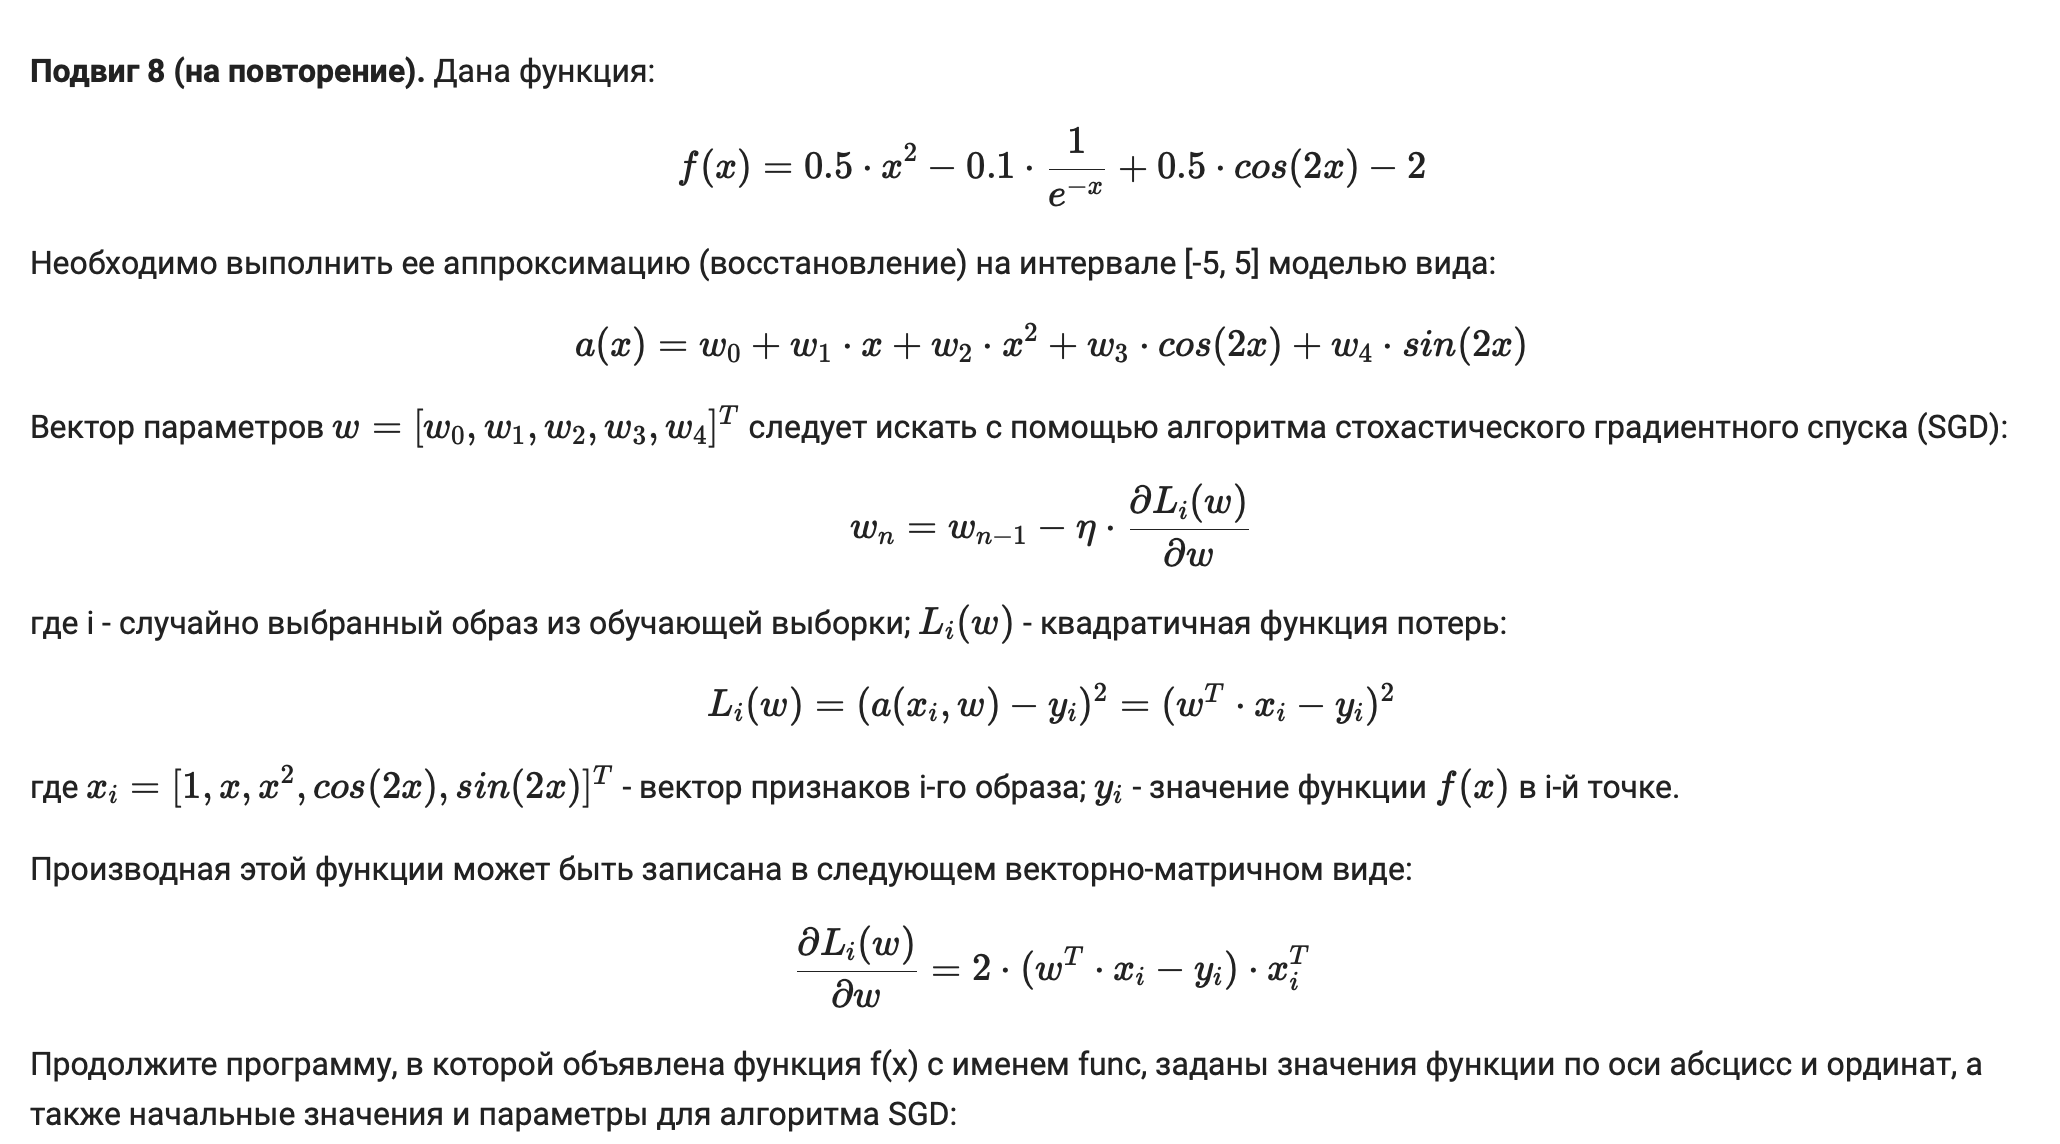
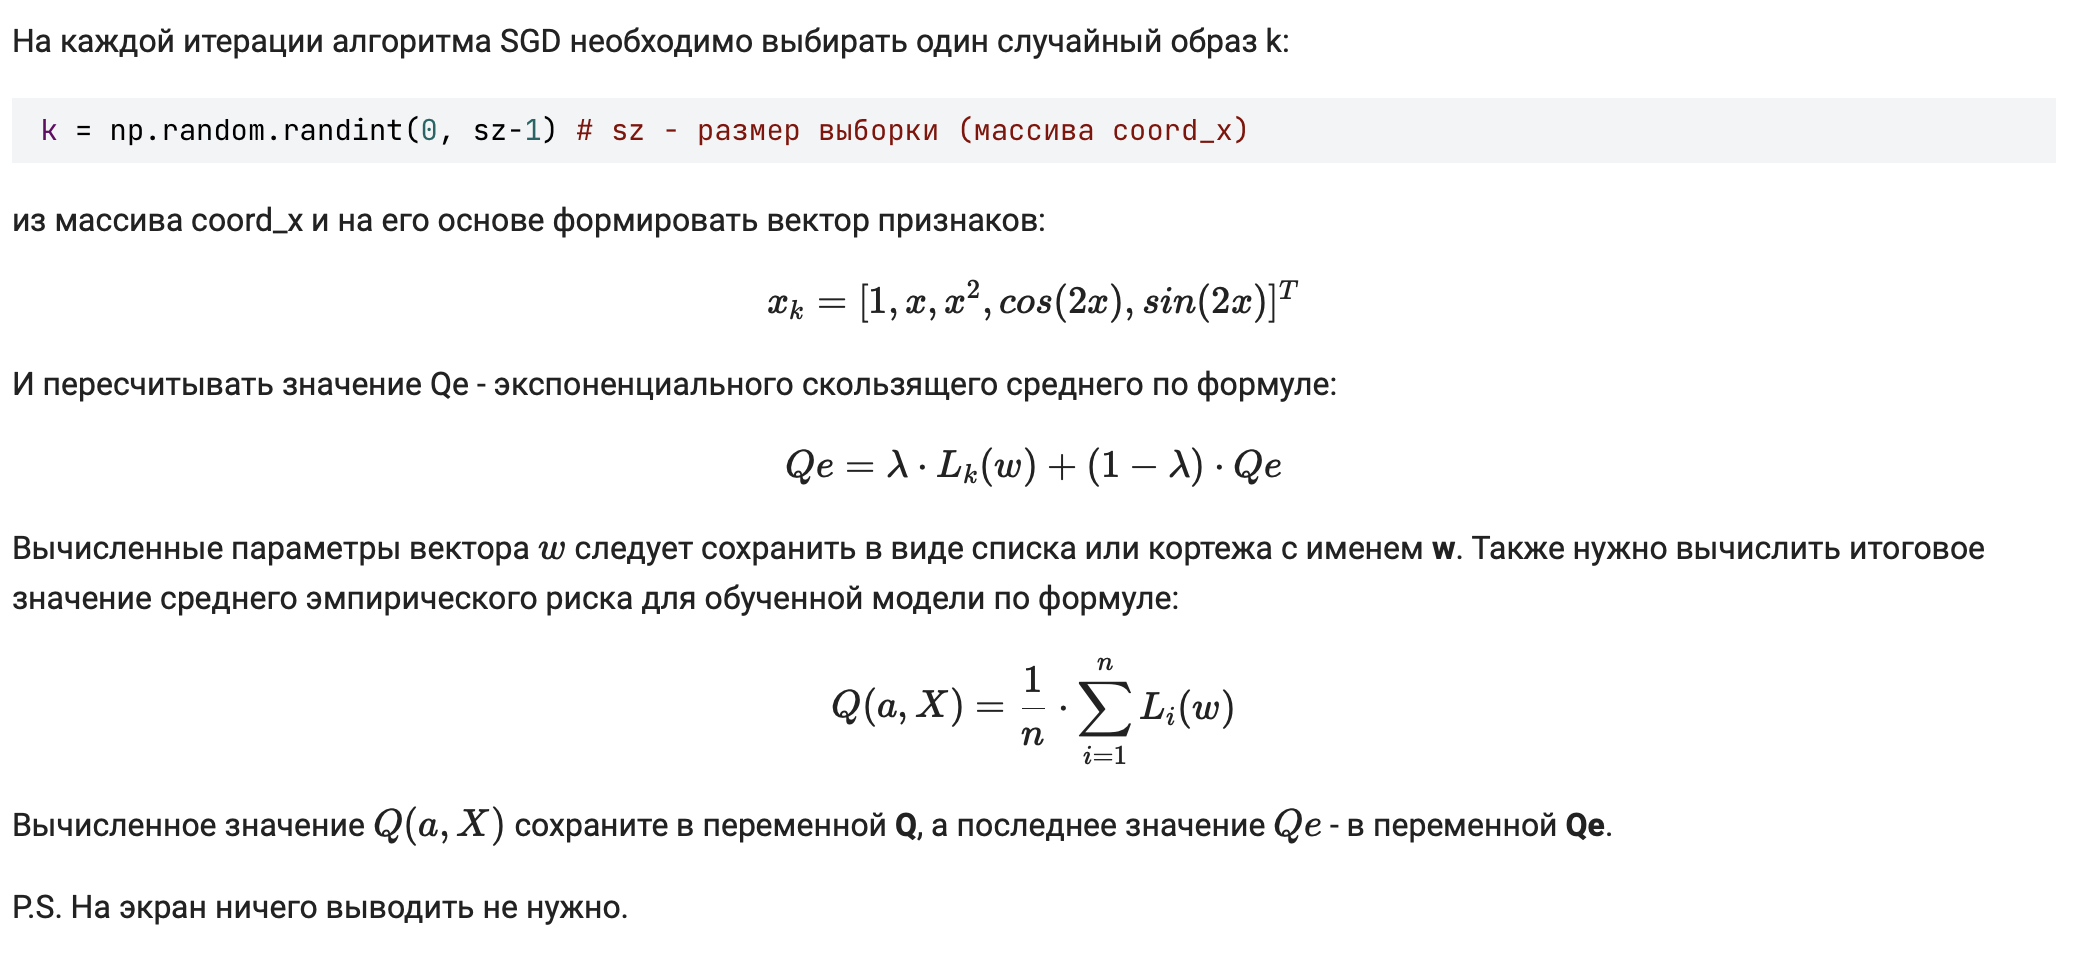

In [12]:
import numpy as np

# исходная функция, которую нужно аппроксимировать моделью a(x)
def func(x):
    return 0.5 * x**2 - 0.1 * 1/np.exp(-x) + 0.5 * np.cos(2*x) - 2.


# здесь объявляйте необходимые функции
def loss(w, x, y):
    return (w @ x.T - y) ** 2

def df(w, x, y):
    return 2 * (w @ x.T - y) * x.T

coord_x = np.arange(-5.0, 5.0, 0.1) # значения по оси абсцисс [-5; 5] с шагом 0.1
coord_y = func(coord_x) # значения функции по оси ординат

X = np.array([[1, xx, xx**2, np.cos(2*xx), np.sin(2*xx)] for xx in coord_x])
Y = coord_y

sz = len(coord_x)	# количество значений функций (точек)
eta = np.array([0.01, 0.001, 0.0001, 0.01, 0.01]) # шаг обучения для каждого параметра w0, w1, w2, w3, w4
w = np.array([0., 0., 0., 0., 0.]) # начальные значения параметров модели
N = 500 # число итераций алгоритма SGD
lm = 0.02 # значение параметра лямбда для вычисления скользящего экспоненциального среднего

Qe = np.mean(loss(w, X, Y)) # начальное значение среднего эмпирического риска
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел

for i in range(N):
    k = np.random.randint(0, sz - 1)
    w -= eta * df(w, X[k], Y[k])
    Qe = lm * loss(w, X[k], Y[k]) + (1 - lm) * Qe
Q = np.mean(loss(w, X, Y))
Q, w

(np.float64(1.4388386249624505),
 array([-1.69244014, -0.72091636,  0.30591752,  0.69383724, -0.24879874]))